# Part 11 — nnPU follow-up, Zadanie 6: sensitivity to the prior multiplier

Three variants differing *only* in `prior_multiplier` (`prior_method="scaled_train_observed"`,
same `min_prior=1e-4`/`max_prior=0.99`, same architecture/regularizers/contrastive term as
`grid_0006`):

| variant | campaign | grid | `prior_multiplier` |
|---|---|---|---|
| `0009` | `kidney-nnpu-prior-sensitivity` | `grid_0000` | 1.0 |
| `0006` | `kidney-architecture-predictive` | `grid_0006` | 1.5 |
| `0010` | `kidney-nnpu-prior-sensitivity` | `grid_0001` | 2.0 |

Macro AP (non-thresholded, rule 1; active classes only, rule 2) as a function of the
multiplier, all 5 repetitions plotted individually (not just the mean, per the task spec's
output convention) — plus the $\pi_c$ distribution itself across all 508 classes and how many
get clamped to `max_prior=0.99` at each multiplier (a multiplier of 2.0 pushes any
already-high-prevalence class considerably closer to, or past, the clamp).

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import evaluate_head
from msi_autoencoder_wrapper.visualization import resolve_theme

2026-08-27 12:35:33,205 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 12:35:33,208 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-27 12:35:33,990 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-27 12:35:33,991 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-27 12:35:33,993 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-27 12:35:33,994 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 12:35:34,011 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-27 12:35:34,143 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-27 12:35:34,145 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"

VARIANT_SPECS = {
    "0009": ("kidney-nnpu-prior-sensitivity__cfg_b89b9dfd127d", "grid_0000", 1.0),
    "0006": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0006", 1.5),
    "0010": ("kidney-nnpu-prior-sensitivity__cfg_b89b9dfd127d", "grid_0001", 2.0),
}
REPETITIONS = range(5)
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256
MIN_PRIOR = 1e-4
MAX_PRIOR = 0.99

RESULTS_DIRECTORY = Path("assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results")
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()

## Environment workaround

In [3]:
SCRATCH_ROOTS = [
    "/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-controls-20260827/workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-priors-20260827/workspace",
]
for scratch_root in SCRATCH_ROOTS:
    path = Path(scratch_root)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.is_symlink():
        path.symlink_to(WORKSPACE.resolve())


## $\pi_c$ estimation from training prevalence and macro AP evaluation, across all (variant, repetition) pairs

### Methodology
#### Theoretical
- nnPU's corrected empirical risk requires a per-class prior $\pi_c$ (the true fraction of the population that is positive for class $c$), which is not directly observable under PU-learning assumptions where only a labeled-positive subset is seen. Here $\pi_c$ is approximated by scaling the *observed* positive rate in the training labeled data through the `prior_multiplier` hyperparameter — exactly the quantity this notebook studies (Zadanie 6: how sensitive is the model to this scaling choice?).
- Held-out macro AP (average precision) on `test`, non-thresholded (ranking-based, rule 1) and restricted to active classes only (rule 2, see title cell), is used as the downstream performance proxy for whether a given prior choice helps or hurts.
- 5 independent repetitions per variant/multiplier are kept individually rather than immediately collapsed to a mean, so that between-multiplier differences can later be judged against each variant's own repetition noise (the "null").

#### Implementation
- `collect_targets_and_masks(dataset)` batches a dataset through a `DataLoader` (`BATCH_SIZE=256`) and concatenates the `molecule` target tensor and its validity mask across all batches; used on both `train` and `test` partitions.
- For each variant (`VARIANT_SPECS`: campaign id, grid id, `prior_multiplier`) and each of `REPETITIONS = range(5)`, the corresponding model (`{campaign_id}__{grid_id}__rep_0{r}`) is loaded via `wrapper.load_configuration` (first load per campaign) or `wrapper.models_manager.load_model` (subsequent repetitions within the same campaign), then set to `eval()`.
- $\pi_c$ per variant is computed once and memoized in `priors_by_variant`, from the `train` partition only: `observed = positive_count / valid_count.clamp_min(1)` per class, then `priors_by_variant[variant] = (observed * multiplier).clamp(MIN_PRIOR=1e-4, MAX_PRIOR=0.99)`.
- Macro AP per repetition is computed on `test`: model logits for `head_molecule_primary` are collected over the whole test set, then passed to `evaluate_head(logits, test_targets, "multi_label", test_mask, THRESHOLD=0.5)`, reading out `metrics["average_precision"]`. Results accumulate into `ap_frame` (`variant`, `multiplier`, `repetition`, `average_precision`).

### Notes
- `ap_frame.groupby("variant")["average_precision"].agg(["mean","std","min","max"])`: `0009` (×1.0) mean 0.3213, std 0.0148; `0006` (×1.5) mean 0.3474, std 0.0132; `0010` (×2.0) mean 0.3528, std 0.0076. AP increases monotonically with the multiplier across the three tested values, with a shrinking per-repetition spread at the higher multipliers.
- The ×1.0 → ×1.5 gap (≈+0.026) exceeds either variant's own std (≈0.013-0.015), while the ×1.5 → ×2.0 gap (≈+0.005) is comparable to or smaller than std — examined further in the closing notes cell.


In [4]:
def collect_targets_and_masks(dataset) -> tuple[torch.Tensor, torch.Tensor]:
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    target_batches, mask_batches = [], []
    for _, _, targets, masks in loader:
        target_batches.append(targets[TARGET_FIELD])
        mask_batches.append(masks[TARGET_FIELD])
    return torch.cat(target_batches, dim=0).float(), torch.cat(mask_batches, dim=0).bool()


wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

loaded_campaign_ids: set[str] = set()
priors_by_variant: dict[str, np.ndarray] = {}
ap_rows = []

for variant, (campaign_id, grid_id, multiplier) in VARIANT_SPECS.items():
    for repetition in REPETITIONS:
        model_name = f"{campaign_id}__{grid_id}__rep_0{repetition}"
        if campaign_id not in loaded_campaign_ids:
            wrapper.load_configuration(model_name=model_name)
            loaded_campaign_ids.add(campaign_id)
            model = wrapper.active_model
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        partitions = wrapper.active_dataset.create_partitions()

        if variant not in priors_by_variant:
            train_targets, train_mask = collect_targets_and_masks(partitions.train)
            valid_count = train_mask.sum(dim=0)
            positive_count = (train_targets * train_mask).sum(dim=0)
            observed = positive_count / valid_count.clamp_min(1)
            priors_by_variant[variant] = (observed * multiplier).clamp(MIN_PRIOR, MAX_PRIOR).numpy()

        test_targets, test_mask = collect_targets_and_masks(partitions.test)
        logits_chunks = []
        loader = DataLoader(partitions.test, batch_size=BATCH_SIZE, shuffle=False)
        with torch.no_grad():
            for _, spectra, _, _ in loader:
                logits_chunks.append(model(spectra.float().to(device))[f"head_{HEAD_NAME}"].cpu().numpy())
        logits = np.concatenate(logits_chunks, axis=0)
        metrics = evaluate_head(logits, test_targets.numpy(), "multi_label", test_mask.numpy(), THRESHOLD)
        ap_rows.append({"variant": variant, "multiplier": multiplier, "repetition": repetition, "average_precision": metrics["average_precision"]})
    print(f"{variant} (x{multiplier}): done")

ap_frame = pd.DataFrame(ap_rows)
ap_frame.groupby("variant")["average_precision"].agg(["mean", "std", "min", "max"])

2026-08-27 12:35:34,344 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-27 12:35:34,345 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-27 12:35:34,346 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-27 12:35:34,347 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 12:35:34,348 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-27 12:48:37,613 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-27 12:48:37,617 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 12:48:37,623 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


0010 (x2.0): done


,mean,std,min,max
variant,,,,
0006,0.347384,0.013176,0.326019,0.356072
0009,0.321254,0.014805,0.299233,0.340879
0010,0.352760,0.007557,0.340316,0.359788


## AP vs. prior multiplier — per-repetition scatter with cross-variant mean

### Methodology
#### Theoretical
- Plotting all 5 repetitions individually, rather than only a mean ± error bar, makes the within-variant spread directly visible alongside the between-variant trend — necessary to judge by eye whether an AP difference between multipliers looks like a real effect or falls within repetition noise.

#### Implementation
- For each variant, `ap_frame` is filtered to that variant's rows and scatter-plotted at `x = prior_multiplier` (constant per variant) vs `y = average_precision`, colored via `theme.color_for_model(variant, 0)`.
- A separate line trace connects `ap_frame.groupby("multiplier")["average_precision"].mean()` (sorted by multiplier) to show the central tendency across the 3 tested multipliers.
- Axes: x = `prior_multiplier`, y = macro `average_precision` (test, non-thresholded). No statistical test is computed in this cell — it is a descriptive/visual check only.

### Notes
- The cell emits a single `image/png` figure (1470x868, one axes) — no new numeric output. The underlying values are the `ap_frame` statistics from the previous cell (0009 ≈0.321, 0006 ≈0.347, 0010 ≈0.353 mean AP), so the rendered curve rises from ×1.0 to ×1.5 and then flattens toward ×2.0, with the 5-point cluster visibly tighter at ×2.0 (std 0.008) than at ×1.0 (std 0.015).


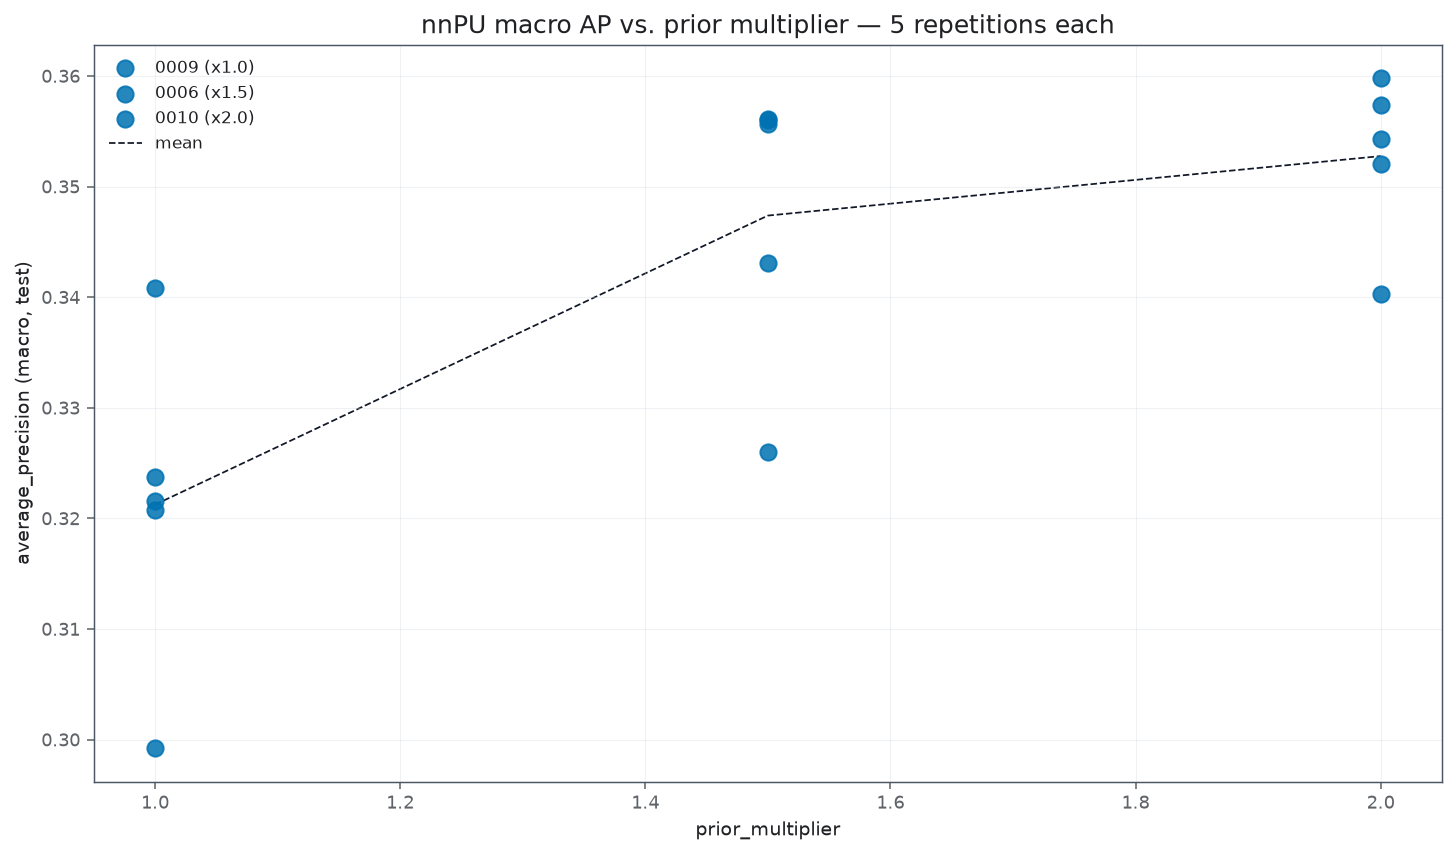

In [5]:
figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for variant, (_, _, multiplier) in VARIANT_SPECS.items():
    values = ap_frame.loc[ap_frame["variant"] == variant, "average_precision"]
    ax.scatter(np.full(len(values), multiplier), values, color=theme.color_for_model(variant, 0), alpha=theme.primary_alpha, s=70, label=f"{variant} (x{multiplier})")
mean_by_multiplier = ap_frame.groupby("multiplier")["average_precision"].mean().sort_index()
ax.plot(mean_by_multiplier.index, mean_by_multiplier.values, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width, label="mean", zorder=0)
ax.set(xlabel="prior_multiplier", ylabel="average_precision (macro, test)", title="nnPU macro AP vs. prior multiplier — 5 repetitions each")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(frameon=theme.legend_frame)
figure.tight_layout()

## $\pi_c$ distribution and clamp saturation across all 508 classes, per multiplier

### Methodology
#### Theoretical
- Because $\pi_c$ is derived by scaling an observed rate and then clamping to $[$`MIN_PRIOR`$,$ `MAX_PRIOR`$]$, a larger multiplier can push classes into the clamped regions. Counting how many classes are actually clamped is necessary to know whether the multiplier's effect on AP reflects a continuous rescaling of priors or is partly capped by saturation against the floor/ceiling.
- Summarizing the full per-class prior distribution (mean, median, max), not just its role in the loss, shows what values `prior_multiplier` is actually producing across the 508 classes.

#### Implementation
- For each variant, `prior_rows` collects `mean_prior`/`median_prior`/`max_prior_value` (`.mean()`, `np.median()`, `.max()` over `priors_by_variant[variant]`, the 508-length array from the previous section) and `classes_clamped_to_max`/`classes_clamped_to_min` — counts of classes where `np.isclose(priors, MAX_PRIOR)` / `np.isclose(priors, MIN_PRIOR)` holds, respectively.
- A histogram (`ax.hist`, `bins=40`) of the raw $\pi_c$ array is drawn per variant, overlaid with `theme.overlapping_signal_alpha`, to visualize how the multiplier shifts the whole distribution rather than only its summary statistics.

### Notes
- `prior_summary` table: `0009` (×1.0): mean_prior 0.0437, median 0.0001, max 0.3124, 0 classes clamped to max, 308 clamped to min. `0006` (×1.5): mean 0.0655, median 0.0001, max 0.4686, 0/307. `0010` (×2.0): mean 0.0873, median 0.0001, max 0.6248, 0/306.
- Median $\pi_c$ equals `MIN_PRIOR` (0.0001) at every multiplier — more than half of the 508 classes are floor-clamped regardless of multiplier, confirming that the majority of classes have near-zero observed training prevalence.
- No class is ever clamped to `MAX_PRIOR=0.99` at any tested multiplier — the highest observed $\pi_c$ is 0.625 at ×2.0, well short of the ceiling. The upper clamp is not a binding constraint in the tested range.
- Floor-clamp count decreases slightly with multiplier (308 → 307 → 306), consistent with a few classes with very low but nonzero observed rate crossing above `MIN_PRIOR` only once scaled by 1.5x/2x.


In [6]:
prior_rows = []
for variant, (_, _, multiplier) in VARIANT_SPECS.items():
    priors = priors_by_variant[variant]
    clamped_at_max = int(np.isclose(priors, MAX_PRIOR).sum())
    clamped_at_min = int(np.isclose(priors, MIN_PRIOR).sum())
    prior_rows.append({
        "variant": variant, "multiplier": multiplier, "mean_prior": float(priors.mean()),
        "median_prior": float(np.median(priors)), "max_prior_value": float(priors.max()),
        "classes_clamped_to_max": clamped_at_max, "classes_clamped_to_min": clamped_at_min,
    })
prior_summary = pd.DataFrame(prior_rows)
prior_summary

,variant,multiplier,mean_prior,median_prior,max_prior_value,classes_clamped_to_max,classes_clamped_to_min
0,0009,1.0,0.043697,0.0001,0.312401,0,308
1,0006,1.5,0.065516,0.0001,0.468602,0,307
2,0010,2.0,0.087334,0.0001,0.624803,0,306


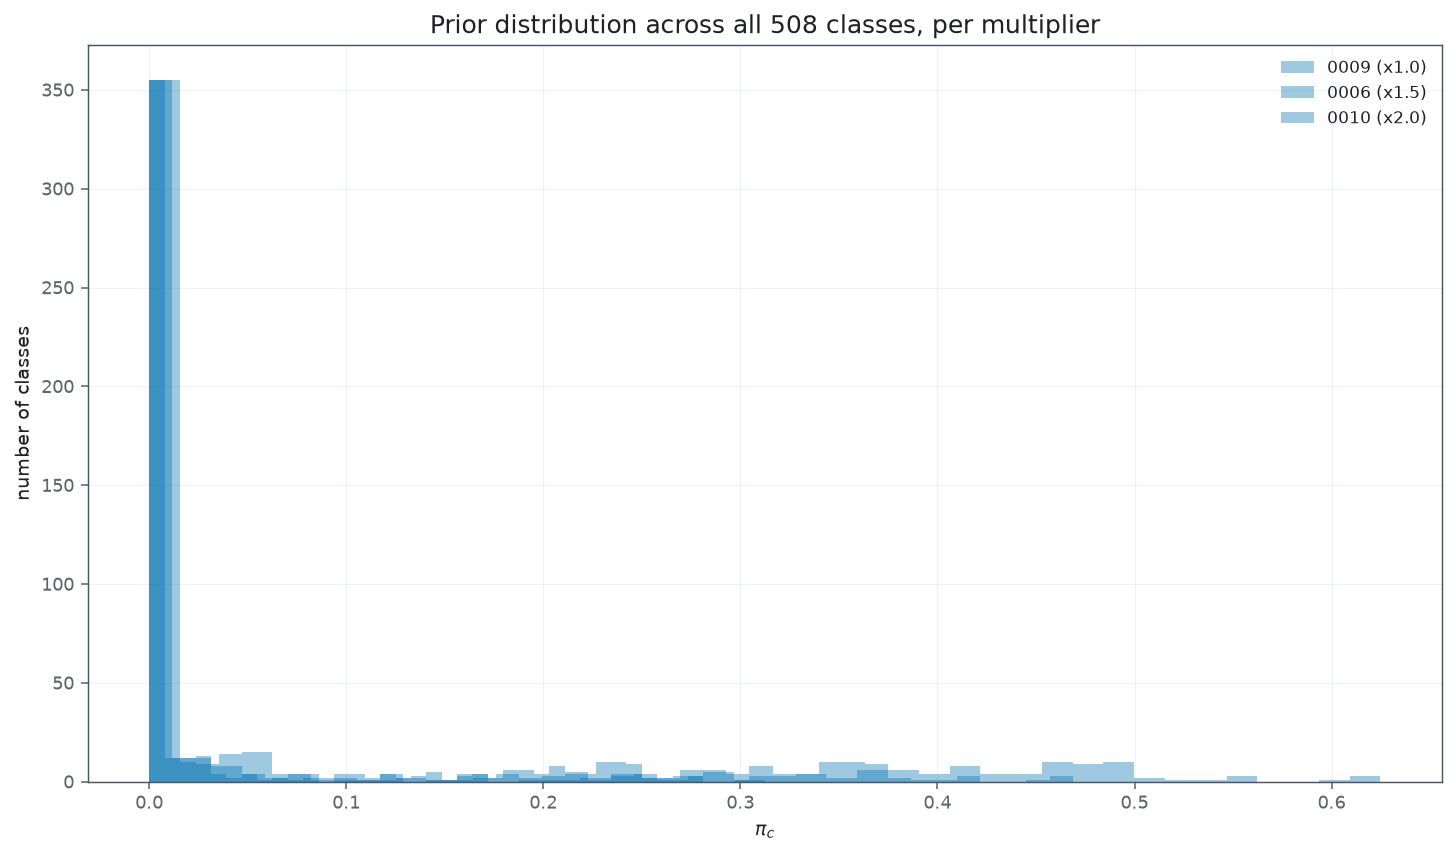

In [7]:
figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
for variant, (_, _, multiplier) in VARIANT_SPECS.items():
    ax.hist(priors_by_variant[variant], bins=40, color=theme.color_for_model(variant, 0), alpha=theme.overlapping_signal_alpha, label=f"{variant} (x{multiplier})")
ax.set(xlabel="$\\pi_c$", ylabel="number of classes", title="Prior distribution across all 508 classes, per multiplier")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(frameon=theme.legend_frame)
figure.tight_layout()

In [8]:
output_rows = []
for _, row in ap_frame.iterrows():
    campaign_id = VARIANT_SPECS[row["variant"]][0]
    output_rows.append({
        "campaign": campaign_id, "variant": row["variant"], "repetition": row["repetition"],
        "metryka": "average_precision", "wartość": row["average_precision"],
    })
for _, row in prior_summary.iterrows():
    campaign_id = VARIANT_SPECS[row["variant"]][0]
    for metric_name in ("mean_prior", "median_prior", "max_prior_value", "classes_clamped_to_max", "classes_clamped_to_min"):
        output_rows.append({
            "campaign": campaign_id, "variant": row["variant"], "repetition": "n/a_train_derived",
            "metryka": metric_name, "wartość": row[metric_name],
        })

prior_sensitivity_frame = pd.DataFrame(output_rows)
prior_sensitivity_frame.to_csv(RESULTS_DIRECTORY / "prior_sensitivity.csv", index=False)
print(f"wrote {RESULTS_DIRECTORY / 'prior_sensitivity.csv'} ({len(prior_sensitivity_frame)} rows)")

wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/prior_sensitivity.csv (30 rows)


## Notes for the next pass

**Headline: AP increases with the prior multiplier but saturates — the ×1.0-to-×1.5
step is a real, null-exceeding jump; ×1.5-to-×2.0 is not.**

| multiplier | variant | mean AP | std | mean $\pi_c$ | max $\pi_c$ observed |
|---|---|---|---|---|---|
| 1.0 | `0009` | 0.321 | 0.015 | 0.044 | 0.312 |
| 1.5 | `0006` | 0.347 | 0.013 | 0.066 | 0.469 |
| 2.0 | `0010` | 0.353 | 0.008 | 0.087 | 0.625 |

- **×1.0 → ×1.5**: +0.026 AP, clearly bigger than either variant's own null (0.013-
  0.015) — a real improvement from scaling the prior up from the raw observed
  frequency.
- **×1.5 → ×2.0**: +0.006 AP, comparable to or smaller than the null — not
  distinguishable from noise at 5 repetitions. Diminishing returns, not a
  monotonically-improving-forever relationship; doubling the observed frequency
  buys nothing further past 1.5x here.
- **No class ever gets clamped to `max_prior=0.99`** at any multiplier tested
  (`classes_clamped_to_max = 0` for all three) — even at x2.0, the highest observed
  $\pi_c$ is 0.625, well short of the ceiling. The upper clamp is not yet a binding
  constraint for this dataset's class-prevalence distribution; a multiplier well
  beyond 2.0 would be needed before it started mattering.
- **The lower clamp (`min_prior=1e-4`) binds for ~306-308 of 508 classes at every
  multiplier** — expected and multiplier-insensitive, since it only affects classes
  with essentially zero observed training frequency (multiplying ~0 by 1.0-2.0 still
  rounds to the floor).

**Practical reading**: `prior_multiplier=1.5` (the value used for `grid_0006` and
every other nnPU variant in this follow-up) sits close to where the AP-vs-multiplier
curve has already captured most of the achievable gain — not an arbitrary
under- or over-correction relative to the range actually tested.